<a href="https://colab.research.google.com/github/ArdhanFah/PCVK/blob/main/Week-01/Pertemuan_2b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**D2. Pengenalan Python untuk membaca dan menampilkan image dengan pengenalan macam-macam Library (Numpy, pandas, cv2, skimage, PIL dan matplotlib)**

**Langkah (Step) 1**

Pada code awal, beberapa library yang akan digunakan adalah: **numpy, pandas, cv2, skimage, PIL, matplotlib**

* **Numpy** adalah library manipulasi array yang digunakan untuk aljabar linear, transformasi Fourier, dan kemampuan pembangkitan angka acak.

* **Pandas** adalah library untuk manipulasi data dan analisis data.

* **CV2** adalah library untuk tugas-tugas computer vision.

* **Skimage** adalah library yang mendukung aplikasi pengolahan citra (image processing) di Python.

* **Matplotlib** adalah library yang menghasilkan figur visualisasi dan menyediakan toolkit antarmuka grafis (GUI).

In [2]:
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt

**Langkah (Step) 2:**

Baca Image dari URLs - Read Image From URLs

Pada Langkah ini kita akan membaca image dari URLs, menampilkannya menggunakan OpenCV, perhatikan ada perbedaan ketika membuka image dalam RGB dan BGR. Channel Warna default untuk OpenCV adalah BGR.

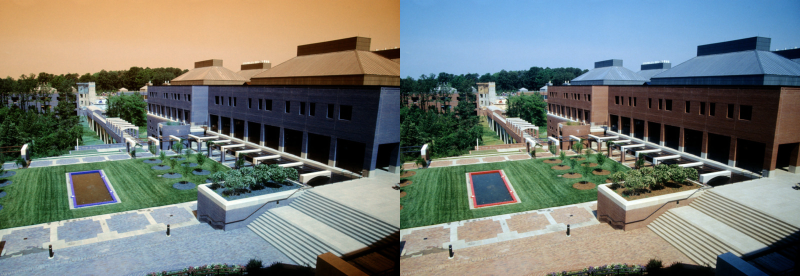

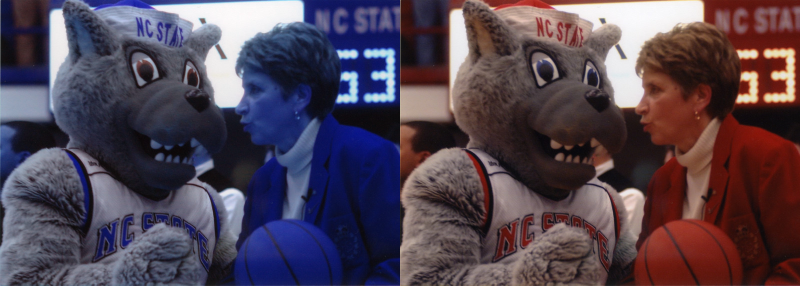



Gagal memuat https://placekitten.com/800/571: HTTP Error 521: <none>



In [3]:
urls = ["https://iiif.lib.ncsu.edu/iiif/0052574/full/800,/0/default.jpg",
        "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg",
        "https://placekitten.com/800/571"]

for url in urls:
  try:
    image = io.imread(url)
    image = cv.resize(image, (0,0), fx=0.5, fy=0.5)
    image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
    final_frame = cv.hconcat((image, image_2))
    cv2_imshow(final_frame)
    print('\n')
  except Exception as e:
    print(f"Gagal memuat {url}: {e}\n")

**Langkahh (Step) 3**

melihat ukuran File image

resolusi image: tinggi  x lebar =  286  x  400


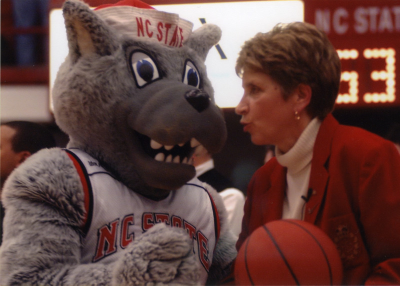

In [4]:
tinggi = image_2.shape[0]
lebar = image_2.shape[1]
print("resolusi image: tinggi  x lebar = ",tinggi, " x ", lebar)
cv2_imshow(image_2)

**Langkah (Step) 4**

mengakses pixel dengan memberi garis diagonal menyilang


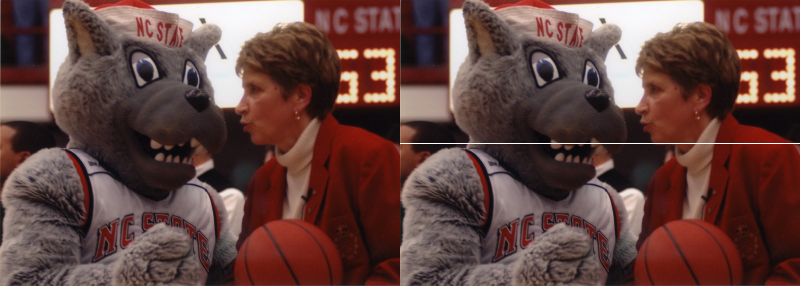

In [5]:
image_0 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_1 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

#membuat garis horizontal ditengah image
for y in range (lebar):
  image_1[int((tinggi)/2), y] = [255,255,255]

final_frame = cv.hconcat((image_0, image_1))
cv2_imshow(final_frame)

#**PERTANYAAN PRAKTIKUM D2**

1. Jelaskan, mengapa pada modul praktikum ini eksekusi kode Python dilakukan
menggunakan Google Colab?

    **Jawaban** : Karena Google Collab mudah digunakan dan berbasis cloud sehingga tidak memerlukan konfigurasi atau instalasi library di komputer lokal, menyediakan akses GPU/TPU gratis untuk pemrosesan citra dan pembelajaran mesin, serta terintegrasi langsung dengan Google Drive dan GitHub untuk memudahkan penyimpanan data dan kolaborasi

2. Jelaskan mengenai kegunaan setiap library pada praktikum langkah ke
delapan?
    **Jawaban** :
      * **Numpy** adalah library manipulasi array yang digunakan untuk aljabar linear, transformasi Fourier, dan kemampuan pembangkitan angka acak.
      * **Pandas** adalah library untuk manipulasi data dan analisis data.
      * **CV2** adalah library untuk tugas-tugas computer vision.
      * **Skimage** adalah library yang mendukung aplikasi pengolahan citra (image processing) di Python.
      * **Matplotlib** adalah library yang menghasilkan figur visualisasi dan menyediakan toolkit antarmuka grafis (GUI).
  
    Apakah semua library tersebut harus digunakan dalam praktikum sesi ini?
    
    **Jawaban** : **Tidak**, Untuk sesi pengujian dasar membaca dan menampilkan gambar dari URL, cukup menggunakan skimage.io, cv2, dan google.colab.patches.cv2_imshow. Library seperti pandas tidak terpakai dalam langkah dasar pemrosesan citra tersebut.


      
3. Pada uji coba langkah ke-9 terdapat potongan kode program sebagai berikut :
image.png
    Apa kegunaan kode program tersebut? dan apa pengaruhnya jika tidak
    dilakukan?
    **Jawaban** : Memperkecil resolusi dimensi citra sebesar 50% (faktor skala 0,5 untuk sumbu horizontal fx dan sumbu vertikal fy

4. Perhatikan potongan kode progam berikut:

    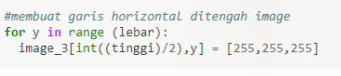

    Apakah kegunaan kode [255,255,255] ? Jelaskan!

    **Jawaban** : Mengatur intensitas maksimum 3 kanal warna (Red, Green, Blue = 255) untuk menghasilkan warna putih murni, yang digunakan pada perulangan untuk membuat garis horizontal di tengah citra.

5. Jelaskan keterkaitan antara pixel dan juga resolusi gambar yang tinggi ataupun
rendah!

    **Jawaban** :  Piksel adalah unit terkecil penyusun citra digital. Semakin banyak dan rapat jumlah pikselnya, semakin tinggi resolusinya sehingga gambar jadi tajam dan tidak pecah. Sebaliknya, makin sedikit pikselnya, makin rendah resolusinya dan gambar akan buram/pecah


**Tugas Praktikum D2**

Buat garis vertikal dan garis menyilang diagonal pada image keluaran

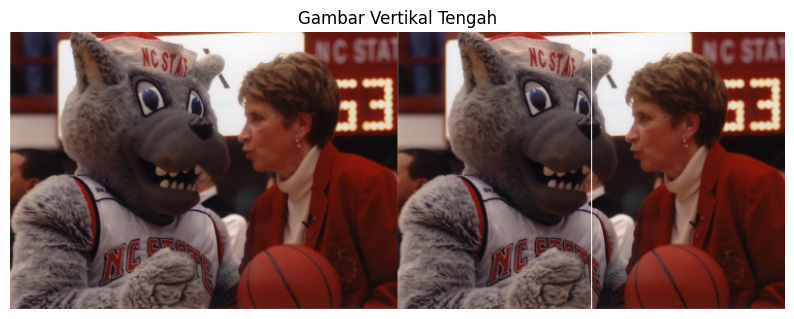

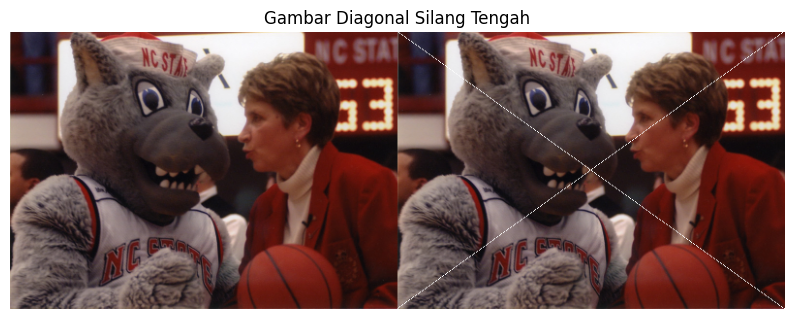

In [6]:
base = image.copy()
h, w, c = base.shape

img_vert = base.copy()
img_diag = base.copy()

mid_x = w // 2
for x in range(h):
  img_vert[x, int(w / 2)] = [255, 255, 255]

for y in range(min(h, w)):
  x1 = int(y * (w - 1) / (h - 1))
  x2 = int((h - 1 - y) * (w - 1) / (h - 1))

  img_diag[y, x1] = [255, 255, 255]
  img_diag[y, x2] = [255, 255, 255]

pair_vert = cv.hconcat([image, img_vert])
pair_diag = cv.hconcat([image, img_diag])

plt.figure(figsize=(10, 5))
plt.imshow(pair_vert)
plt.title("Gambar Vertikal Tengah")
plt.axis("off")
plt.show()

## SILANG
plt.figure(figsize=(10, 5))
plt.imshow(pair_diag)
plt.title("Gambar Diagonal Silang Tengah")
plt.axis("off")
plt.show()

3. Buat garis horisontal berwarna putih dibagian tengah gambar dengan
panjang tertentu


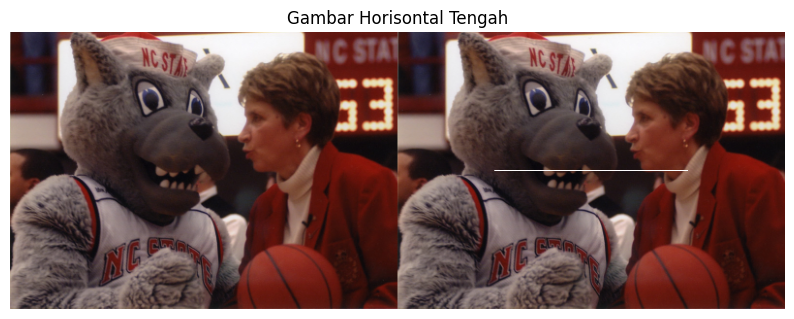

In [7]:
img_horiz = base.copy()
line = 200
mid_y = h // 2

x_start = max(0, (w - line) // 2)
x_end = min(w, (w + line) // 2)

for x in range(x_start, x_end):
    img_horiz[mid_y, x] = [255, 255, 255]


pair_horiz = cv.hconcat([image, img_horiz])

plt.figure(figsize=(10, 5))
plt.imshow(pair_horiz)
plt.title("Gambar Horisontal Tengah")
plt.axis("off")
plt.show()


4. Buat kotak menggunakan kumpulan pixel warna putih di sembarang tempat
dalam gambar

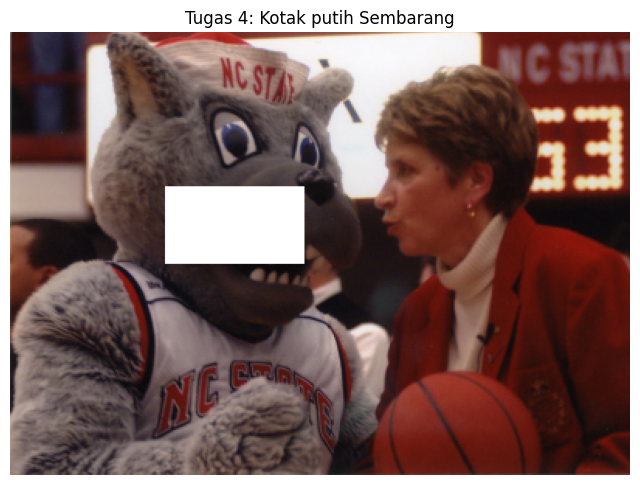

In [8]:
img_rand = base.copy()
img_rand[100:150, 100:190] = [255, 255, 255]

plt.figure(figsize=(8, 8))
plt.imshow(img_rand)
plt.title("Tugas 4: Kotak putih Sembarang")
plt.axis("off")
plt.show()

**D3. Pengenalan Python: Pengolahan Citra Dasar dan memahami channel warna pada OpenCV dan konversinya**

1. Bikin koneksi antara Colab dengan Google Drive agar bisa mengakses
file didalamnya.

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
from google.colab import files
uploaded = files.upload()

Saving KTM.jpeg to KTM.jpeg


Tampilkan gambar KTM

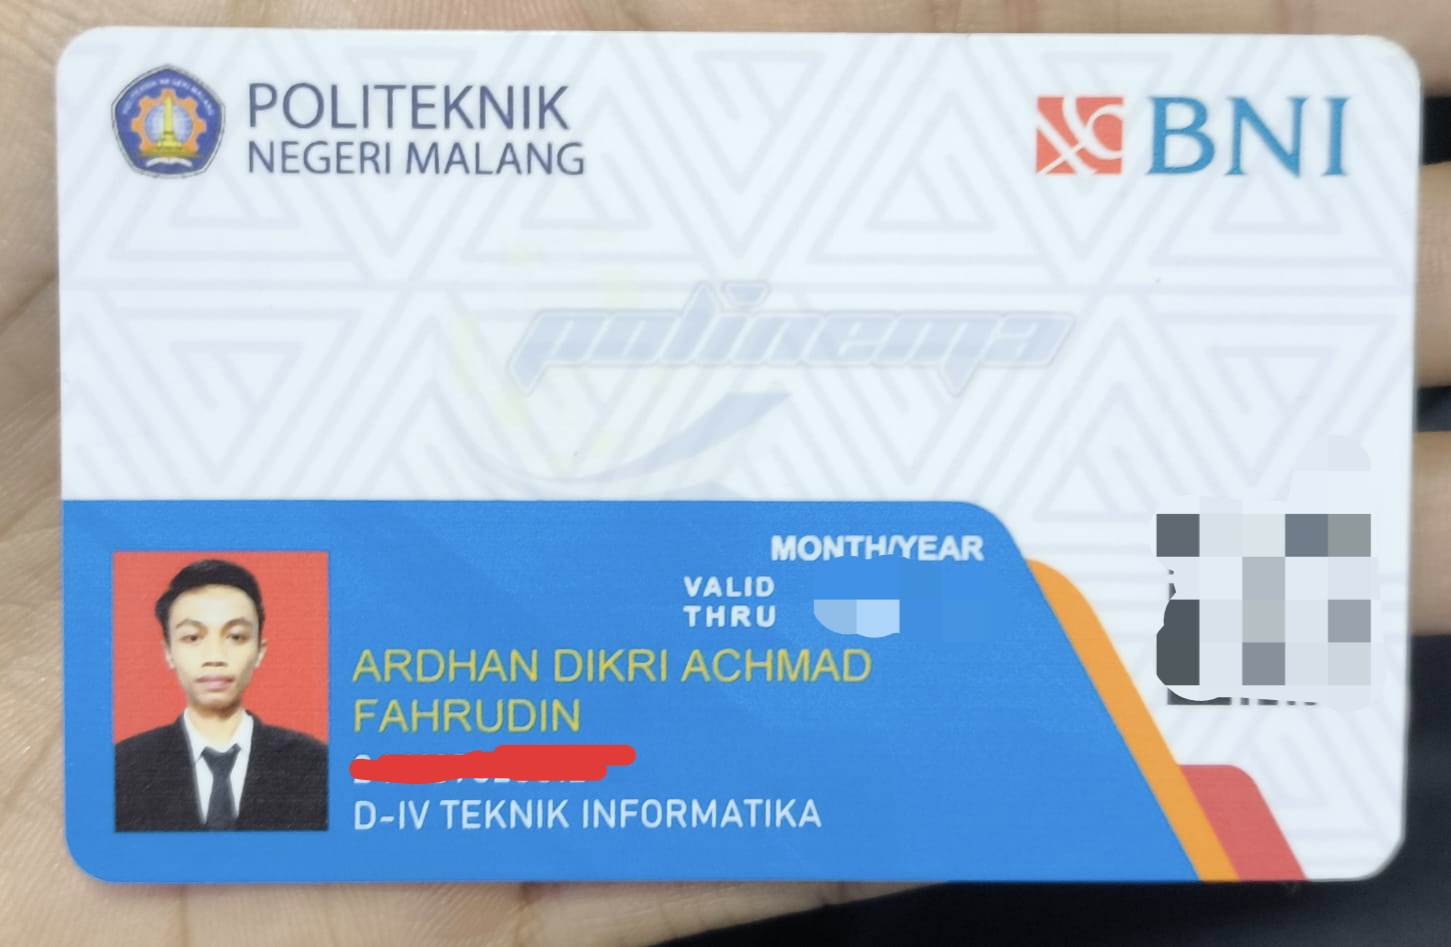

Resolusi gambar: 1451 x 947


In [11]:
from google.colab.patches import cv_imshow

img = cv.imread("KTM.jpeg")
cv_imshow(img)

print("Resolusi gambar:", img.shape[1], "x", img.shape[0])

2. Menampilkan Gambar

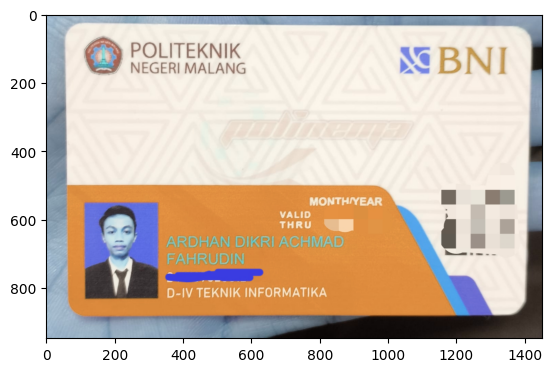

In [12]:
import matplotlib.pyplot as plt

img = cv.imread("/content/drive/MyDrive/PCVK/KTM.jpeg")
plt.imshow(img)

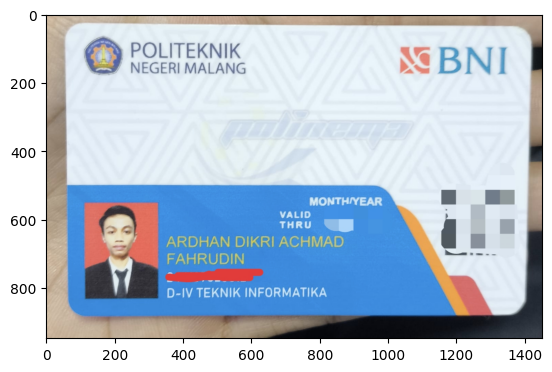

In [13]:
img = cv.imread("/content/drive/MyDrive/PCVK/KTM.jpeg")
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.show()

3. Menampilkan citra Grayscale:

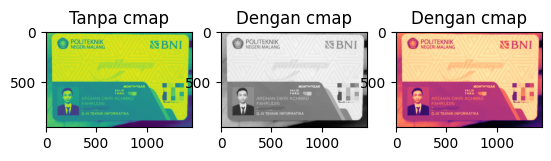

In [14]:
img_gray = cv.imread("/content/drive/MyDrive/PCVK/KTM.jpeg", cv.IMREAD_GRAYSCALE)

#Tanpa cmap
plt.subplot(1,3,1)
plt.imshow(img_gray)
plt.title("Tanpa cmap")

#Dengan cmap
plt.subplot(1,3,2)
plt.imshow(img_gray, cmap="gray")
plt.title("Dengan cmap")

#Dengan cmap
plt.subplot(1,3,3)
plt.imshow(img_gray, cmap="magma")
plt.title("Dengan cmap")

plt.show()

4. Melakukan resizing

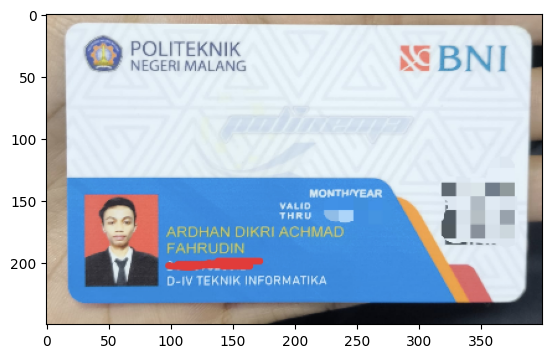

In [15]:
imgRGB=cv.cvtColor(img, cv.COLOR_BGR2RGB)
imgRGBsmall=cv.resize(imgRGB, (400,250))
plt.imshow(imgRGBsmall)

5. Melakukan Flipping

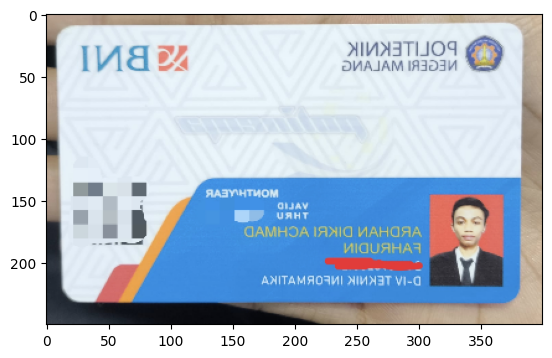

In [16]:
imgBalik = cv.flip(imgRGBsmall, 1)
plt.imshow(imgBalik)

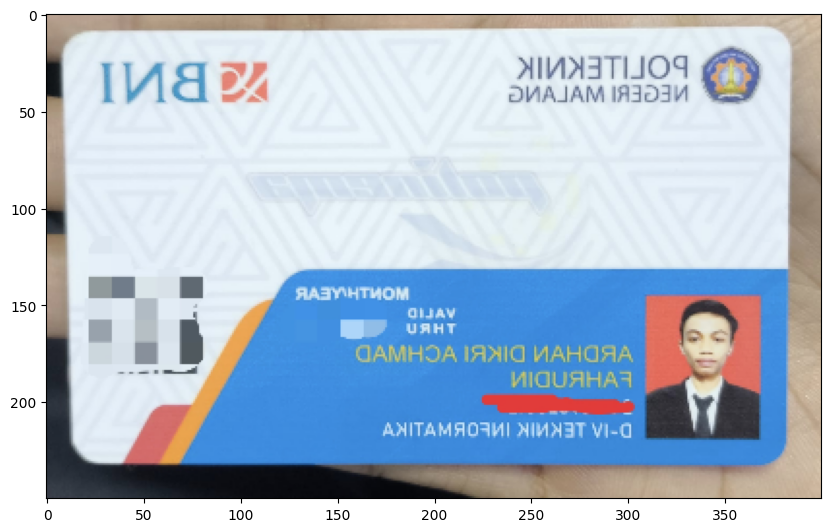

In [17]:
fig = plt.figure(figsize=(10,10))
ax=fig.add_subplot(111)
ax.imshow(imgBalik)

6. Membuat bentuk Geometri 2D dari OpenCV. Diawali dengan pembuatan
black image dengan tipe data int16.

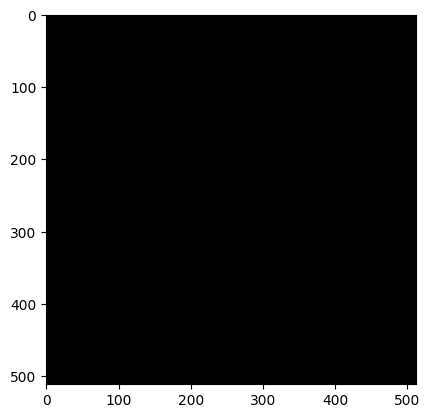

In [18]:
black_img = np.zeros(shape=(512, 512, 3), dtype=np.int16)
plt.imshow(black_img)

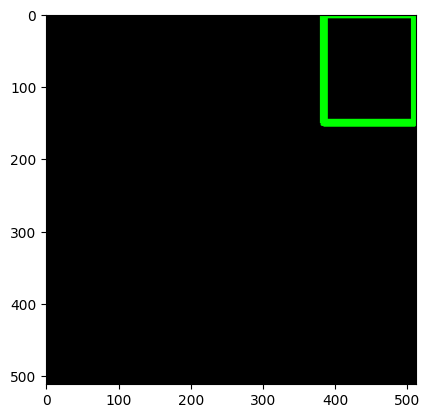

In [19]:
cv.rectangle(black_img,pt1=(384,0),pt2=(510,150), color=(0,255,0), thickness=10)
plt.imshow(black_img)

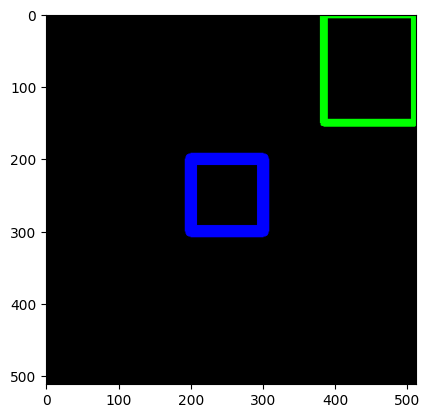

In [20]:
cv.rectangle(black_img, pt1=(200,200), pt2=(300,300), color=(0,0,255), thickness=15)
plt.imshow(black_img)

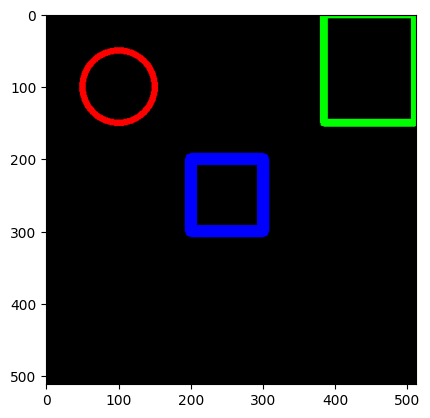

In [21]:
cv.circle(black_img, center=(100,100), radius=50, color=(255,0,0), thickness=8)
plt.imshow(black_img)

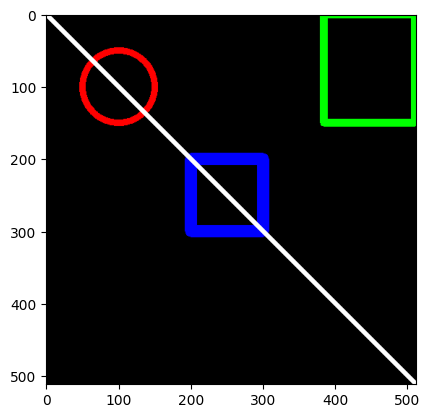

In [22]:
cv.line(black_img, pt1=(0,0), pt2=(512,512), color=(255,255,255), thickness=5)
plt.imshow(black_img)

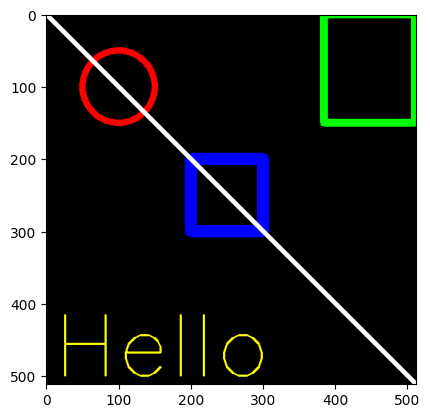

In [23]:
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img, text='Hello', org=(10,500), fontFace=font, fontScale=4, color=(255,255,0), thickness=2, lineType=cv.LINE_AA)
plt.imshow(black_img)

Pembuatan black image kembali dilakukan dengan tipe data int32

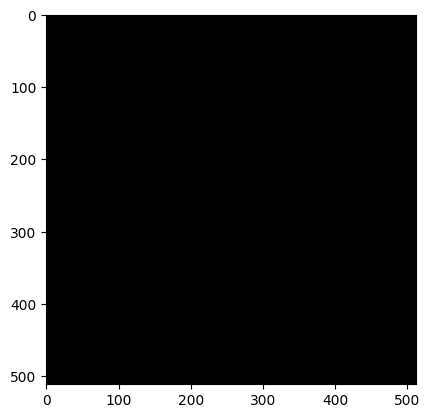

In [24]:
black_img2=np.zeros(shape=(512,512,3), dtype=np.int32)
plt.imshow(black_img2)

In [25]:
vertices = np.array([[100,300], [200,200], [400,300], [200,400]], dtype=np.int32)
vertices

array([[100, 300],
       [200, 200],
       [400, 300],
       [200, 400]], dtype=int32)

In [26]:
pts = vertices.reshape((-1,1,2))
pts

array([[[100, 300]],

       [[200, 200]],

       [[400, 300]],

       [[200, 400]]], dtype=int32)

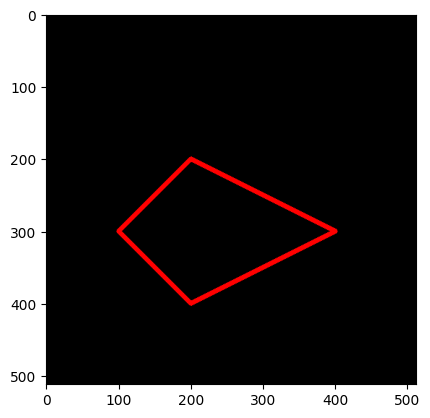

In [27]:
cv.polylines(black_img2,[pts], isClosed=True, color=(255,0,0), thickness=5)
plt.imshow(black_img2)

**PERTANYAAN PRAKTIKUM D3**

1. Apakah perbedaan gambar yang ditampilkan tanpa dan dengan matplotlib
**Jawaban** : Tanpa Matplotlib gambar muncul di jendela baru dengan format warna BGR, sedangkan dengan Matplotlib gambar muncul langsung di notebook dengan format RGB beserta sumbu koordinat piksel.
2. Apakah perbedaan dan pengaruhnya pembuatan black image antara tipe data int16 dan int32?

    **Jawaban** : Tipe data **int32** memakai memori dua kali lebih besar dan rentang angka lebih luas dibanding **int16**, namun keduanya sama-sama menampilkan gambar hitam pekat tanpa perbedaan visual.
3.  Apakah kegunaan “google.colab.patches import cv2_imshow” pada potongan kode berikut

      Pasted image.png
      
     **Jawaban** : Potongan kode tersebut berguna menggantikan fungsi cv2.imshow() bawaan OpenCV agar gambar bisa tampil langsung di notebook Google Colab tanpa menyebabkan eror.

4. Apakah kegunaan “skimage import io” pada potongan kode soal nomor
**Jawaban** : Modul io dari scikit-image berguna untuk membaca file citra dalam format RGB serta menyimpannya kembali ke media penyimpanan.

**TUGAS PRAKTIKUM D3**
1. Dengan menggunakan figsize, perhatikan apakah ukuran image pixelnya juga berubah?

    **Jawaban** : tidak, karena hanya mengubah dimensi tampilan kanvas pada output layar noteboook

2. Tampilkan image dalam channel Red-Blue dan Green-Blue saja!

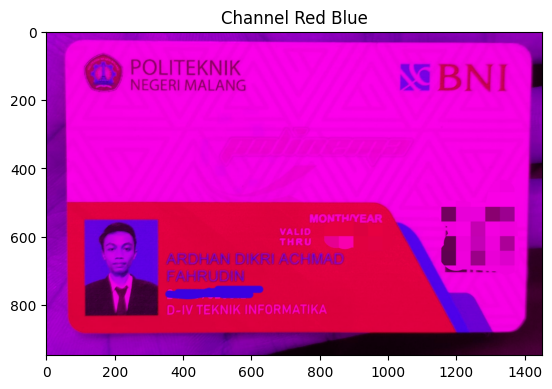

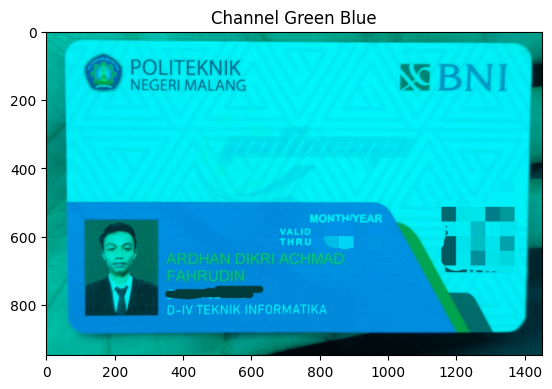

In [28]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

img_bgr = cv.imread('/content/drive/MyDrive/PCVK/KTM.jpeg')
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)


img_rb = img_bgr.copy()
img_rb[:, :, 1] = 0
plt.imshow(img_rb)
plt.title("Channel Red Blue")
plt.show()

img_gb = img_rgb.copy()
img_gb[:, :, 0] = 0
plt.imshow(img_gb)
plt.title("Channel Green Blue")
plt.show()

3. Tampilkan image baris ke 20-115, kolom 25-120!

Text(0.5, 1.0, 'Crop: Baris 20-115, Kolom 25-120')

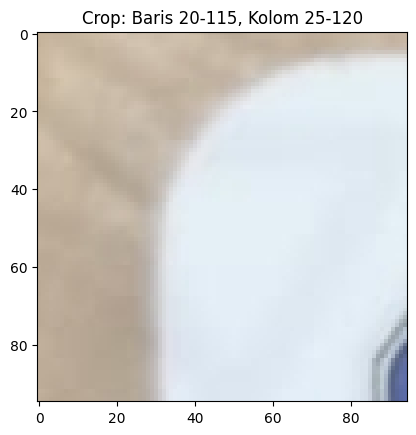

In [29]:
crop_img = img_rgb[20:115, 25:120]
plt.imshow(crop_img)
plt.title("Crop: Baris 20-115, Kolom 25-120")

4. Tampilkan Citra Baris ke-5 sampai 30, Semua Kolom, Channel Red Saja

Text(0.5, 1.0, 'Citra Baris ke-5 sampai 30, Semua Kolom, Channel Red Saja')

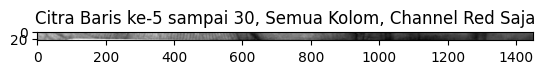

In [30]:
red_sliced = img_rgb[5:30, :, 0]
plt.imshow(red_sliced, cmap='gray')
plt.title("Citra Baris ke-5 sampai 30, Semua Kolom, Channel Red Saja")

5. Buat 5 Kotak Berbagai Ukuran dan Warna Berbeda Menggunakan Nilai Acak (Random)

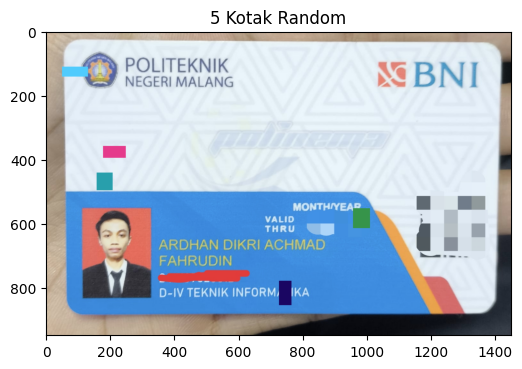

In [31]:
import random

img_boxes = img_rgb.copy()
h, w, _ = img_boxes.shape

for _ in range(5):
    # Koordinat sudut kiri atas (x1, y1)
    x1 = random.randint(0, w - 80)
    y1 = random.randint(0, h - 80)

    # Koordinat sudut kanan bawah (x2, y2)
    x2 = x1 + random.randint(30, 80)
    y2 = y1 + random.randint(30, 80)

    # Warna acak RGB
    color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))

    # Gambar kotak (-1 untuk kotak terisi penuh/fill)
    cv.rectangle(img_boxes, (x1, y1), (x2, y2), color, -1)

plt.figure(figsize=(6, 6))
plt.imshow(img_boxes)
plt.title("5 Kotak Random")
plt.show()

6. Tampilkan Citra dengan Posisi Terbalik

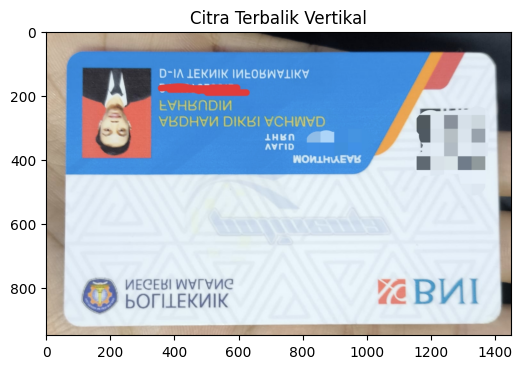

In [32]:
img_flipped = cv.flip(img_rgb, 0)

plt.figure(figsize=(6, 6))
plt.imshow(img_flipped)
plt.title("Citra Terbalik Vertikal")
plt.show()

7. Buat rectangle dan circle pada bagian wajah dari image foto s anda saat beraktifitas (bukan pasfoto).

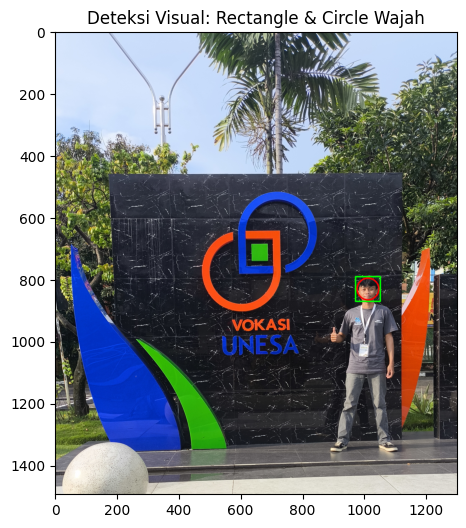

In [59]:
# Membaca foto pribadi beraktivitas
face = cv.imread('/content/drive/MyDrive/PCVK/Aktivitas.jpg')
face = cv.cvtColor(face, cv.COLOR_BGR2RGB)
face = cv.resize(face, (0, 0), fx=0.5, fy=0.5)

img_face = face.copy()
cv.rectangle(img_face, pt1=(970, 790), pt2=(1050, 870), color=(0, 255, 0), thickness=3)
cv.circle(img_face, center=(1010, 830), radius=35, color=(255, 0, 0), thickness=3)

plt.figure(figsize=(6, 6))
plt.imshow(img_face)
plt.title("Deteksi Visual: Rectangle & Circle Wajah")
plt.show()

8. Buat rectangle pada bagian sudut bawah kiri channel B pada color space RGB dari citra kitten/ lena/ mandrill/ male/ female/ couple/sailboat/ peppers!

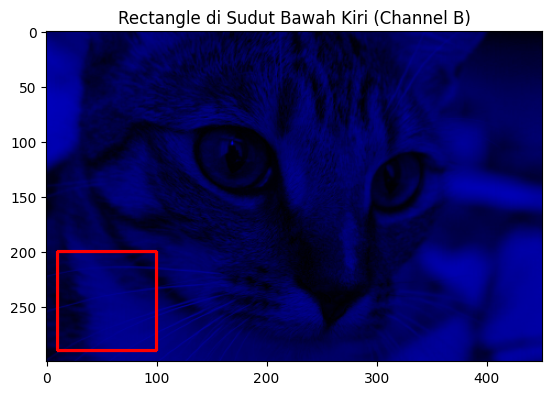

In [79]:
import cv2 as cv
import matplotlib.pyplot as plt
from skimage import data

img = data.chelsea() #pengganti kitten

b_channel = img.copy()
b_channel[:, :, 0] = 0  # Matikan Red
b_channel[:, :, 1] = 0  # Matikan Green
cv.rectangle(b_channel, pt1=(10, 200), pt2=(100, 290), color=255, thickness=2)

plt.imshow(b_channel)
plt.title("Rectangle di Sudut Bawah Kiri (Channel B)")
plt.show()

9. Lengkapi tulisan nama file pada file citra dari soal no.8. gunakan font,
ukuran font, dan warna font yang sesuai keinginan anda.

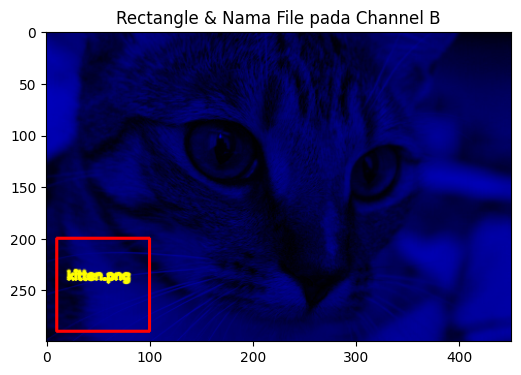

In [80]:
cv.putText(
    img=b_channel,
    text="kitten.png",
    org=(20, 240),
    fontFace=cv.FONT_ITALIC,
    fontScale=0.4,
    color=(255, 255, 0),
    thickness=2,
    lineType=cv.LINE_AA
)

plt.figure(figsize=(6, 6))
plt.imshow(b_channel)
plt.title("Rectangle & Nama File pada Channel B")
plt.show()